In [1]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np
import h5py
#from common import smooth
from matplotlib.ticker import FormatStrFormatter

plt.rc('font', family='Times New Roman', size=14)
plt.rcParams['mathtext.fontset'] = 'custom'

plt.rcParams['mathtext.it'] = 'STIXGeneral:italic'
plt.rcParams['mathtext.rm'] = 'STIXGeneral:bold'
plt.rcParams['mathtext.tt'] = 'STIXGeneral'
plt.rcParams['mathtext.bf'] = 'STIXGeneral:bold:italic'
plt.rcParams['mathtext.cal'] = 'STIXGeneral'
plt.rcParams['mathtext.sf'] = 'STIXGeneral'

plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.linewidth'] = 1.5

itr = r'$R$'
ite = r'$E$'

color_dict = {'HF':'tab:gray',
              'CASSCF':'tab:gray',
              'GW':'tab:red',
              'FCI':'black'}

color_dict = {'HF':'C1',
              'CASSCF':'C0',
              'GW0':'C3',
              'GW1':'C1',
              'GW2':'C2',
              'FCI':'black'}

In [4]:
import numpy as np
from pyscf import gto, scf, mcscf, fci, adc

np.set_printoptions(precision=8)

be = gto.M()
be.atom = 'Be 0. 0. 0.'
be.basis = '6-31G'
be.symmetry = 1
be.build()


In [5]:
rhf = scf.RHF(be)
rhf.kernel()

print('RHF mo_energy, ', rhf.mo_energy)

rhf.analyze(verbose=5)

converged SCF energy = -14.5667640335096
RHF mo_energy,  [-4.7068905  -0.30129539  0.08243534  0.08243534  0.08243534  0.43975431
  0.46493101  0.46493101  0.46493101]
**** SCF Summaries ****
Total Energy =                         -14.566764033509632
Nuclear Repulsion Energy =               0.000000000000000
One-electron Energy =                  -19.117156284041613
Two-electron Energy =                    4.550392250531980
Wave-function symmetry id = 0
occupancy for each irrep:    s+0  p-1  p+0  p+1
                               2    0    0    0
**** MO energy ****
MO #1 (s+0 #1), energy= -4.70689050173316 occ= 2
MO #2 (s+0 #2), energy= -0.301295385243339 occ= 2
MO #3 (p-1 #1), energy= 0.0824353423636101 occ= 0
MO #4 (p+0 #1), energy= 0.0824353423636101 occ= 0
MO #5 (p+1 #1), energy= 0.0824353423636101 occ= 0
MO #6 (s+0 #3), energy= 0.439754310713597 occ= 0
MO #7 (p-1 #2), energy= 0.4649310089216 occ= 0
MO #8 (p+0 #2), energy= 0.4649310089216 occ= 0
MO #9 (p+1 #2), energy= 0.46493100

((array([1.99999997e+00, 1.99969123e+00, 3.08802653e-04, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00]),
  array([0.])),
 array([0., 0., 0.]))

In [4]:
myadc = adc.ADC(rhf)

#IP-RADC(2) for 1 root
myadc.verbose = 6
eip,vip,pip,xip = myadc.kernel(nroots = 6)
myadc.analyze()


******** <class 'pyscf.adc.radc.RADC'> ********
max_memory 4000 MB (current use 190 MB)
******** ADC Orbital Information ********
Number of Frozen Occupied Orbitals: 0
Number of Frozen Virtual Orbitals: 0
Number of Active Occupied Orbitals: 2
Number of Active Virtual Orbitals: 7
*****************************************
    CPU time for ADC integral transformation      0.14 sec, wall time      0.02 sec
    CPU time for Completed t2_1 amplitude calculation      0.01 sec, wall time      0.00 sec
    CPU time for Completed t1_2 amplitude calculation      0.02 sec, wall time      0.00 sec
    CPU time for Completed amplitude calculation      0.01 sec, wall time      0.00 sec
Reference correlation energy (doubles): -0.02431101
MP2 correlation energy of reference state (a.u.) = -0.02431101

******** <class 'pyscf.adc.radc_ip.RADCIP'> ********
max_space = 12
max_cycle = 50
conv_tol = 1e-08
max_memory 4000 MB (current use 191 MB)
    CPU time for Completed M_ij second-order terms ADC(2) calcu

In [5]:
myadc.method = 'adc(3)'
eip,vip,pip,xip = myadc.kernel(nroots=6)

myadc.analyze()


******** <class 'pyscf.adc.radc.RADC'> ********
max_memory 4000 MB (current use 191 MB)
******** ADC Orbital Information ********
Number of Frozen Occupied Orbitals: 0
Number of Frozen Virtual Orbitals: 0
Number of Active Occupied Orbitals: 2
Number of Active Virtual Orbitals: 7
*****************************************
    CPU time for ADC integral transformation      0.04 sec, wall time      0.00 sec
    CPU time for Completed t2_1 amplitude calculation      0.01 sec, wall time      0.00 sec
    CPU time for Completed t1_2 amplitude calculation      0.04 sec, wall time      0.00 sec
    CPU time for Completed t2_2 amplitude calculation      0.01 sec, wall time      0.00 sec
    CPU time for Completed amplitude calculation      0.17 sec, wall time      0.01 sec
Reference correlation energy (doubles): -0.03618317
MP3 correlation energy of reference state (a.u.) = -0.03618317

******** <class 'pyscf.adc.radc_ip.RADCIP'> ********
max_space = 12
max_cycle = 50
conv_tol = 1e-08
max_memory

In [8]:
from gf.gw.srgw import selfen_GW_RHF, gf_from_selfen, iterat_qs_GW_RHF
from pyscf.data.nist import HARTREE2EV as au2ev

qs = iterat_qs_GW_RHF(rhf, qs_lst=[0,1,2,3,4])
print('GW mo_energy, ', qs)

eta = .1/au2ev


Lowest     8 RPA excitation energies:
 [0.38373073 0.38373073 0.38373073 0.38373073 0.38373073 0.38373073
 0.38373073 0.38373073]
GW mo_energy,  [-4.62429423 -0.32067628  0.08228938  0.08228938  0.08228938]


In [6]:
s = selfen_GW_RHF(rhf, eta=eta)
Gsrgw = gf_from_selfen(rhf, s, eta=eta)


Lowest     8 RPA excitation energies:
 [0.38373073 0.38373073 0.38373073 0.38373073 0.38373073 0.38373073
 0.38373073 0.38373073]


In [8]:
from gf.addons import costru_h1e_h2e
from gf.gw.addons import gf_exact_from_mol

#nmo = rhf.mo_coeff.shape[1]
#nelec = (2,2)

#h1e, h2e = costru_h1e_h2e(be, rhf.mo_coeff, rhf._eri)
#Gfci = gf_from_FCI(h1e, h2e, nmo, nelec)

Gfci = gf_exact_from_mol(be, mo_coeff=rhf.mo_coeff, eri=rhf._eri)

======== Ground state FCI coefficients ========
    det-alpha,    det-beta,    CI coefficients
       [0 1]       [0 1]      0.948648577678
       [0 2]       [0 2]      -0.162817607903
       [0 3]       [0 3]      -0.162817651297
       [0 4]       [0 4]      -0.162817159154
======== Electron addition: alpha ========
State id =    0, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 3]       [0 1]      -0.945821908932
       [0 2 3]       [0 2]      0.178812759795
       [0 1 4]       [0 1]      0.127416756346
       [0 3 4]       [0 4]      -0.178812759795
State id =    1, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 3]       [0 1]      0.127416756350
       [0 1 4]       [0 1]      0.945821908957
       [0 2 4]       [0 2]      -0.178812759800
       [0 3 4]       [0 3]      -0.178812759800
State id =    2, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 2]       [0 1]      0.9543658172

In [6]:
from pyscf import cc
from pyscf.data.nist import HARTREE2EV as au2ev

mycc = cc.RCCSD(rhf)
mycc.verbose = 7
mycc.ccsd()


eip,cip = mycc.ipccsd(nroots=2)

print(eip*au2ev)


******** <class 'pyscf.cc.ccsd.CCSD'> ********
CC2 = 0
CCSD nocc = 2, nmo = 9
max_cycle = 50
direct = 0
conv_tol = 1e-07
conv_tol_normt = 1e-05
diis_space = 6
diis_start_cycle = 0
diis_start_energy_diff = 1e+09
max_memory 4000 MB (current use 230 MB)
total FLOPs 90510.0
    CPU time for CCSD integral transformation      1.17 sec, wall time      0.08 sec
Init t2, MP2 energy = -14.5910750443294  E_corr(MP2) -0.0243110108197555
    CPU time for init mp2      0.01 sec, wall time      0.00 sec
Init E_corr(CCSD) = -0.0243110108197555
    CPU time for vvvv [0:2]      0.14 sec, wall time      0.01 sec
    CPU time for vvvv [2:4]      0.18 sec, wall time      0.01 sec
    CPU time for vvvv [4:6]      0.30 sec, wall time      0.02 sec
    CPU time for vvvv [6:7]      0.41 sec, wall time      0.03 sec
    CPU time for vvvv      1.05 sec, wall time      0.07 sec
max_memory 3769 MB,  nocc,nvir = 2,7  blksize = 7
    CPU time for vovv [0:7]      0.16 sec, wall time      0.01 sec
    CPU time for ov

In [6]:
caslst = [1,2,3,4]

#cas = mcscf.CASSCF(rhf, 4, (1,1))

cas = mcscf.CASCI(rhf, 4, (1,1))

#cas.fix_spin_(ss=0.)
mo_coeff = cas.sort_mo(caslst, rhf.mo_coeff, base=0)
cas.kernel(mo_coeff)


WARN: Wave-function symmetry for SO3 not supported. Wfn symmetry is mapped to D2h/C2v group.

CASCI E = -14.5975694860814  E(CI) = -0.987867413523464  S^2 = 0.0000000


(-14.597569486081394,
 -0.987867413523464,
 FCIvector([[ 0.962424  ,  0.        ,  0.        ,  0.        ],
            [ 0.        , -0.15678014,  0.        ,  0.        ],
            [ 0.        ,  0.        , -0.15678014,  0.        ],
            [ 0.        ,  0.        ,  0.        , -0.15678014]]),
 NPArrayWithTag([[ 0.99799582, -0.22265994, -0.        , -0.        ,
                  -0.        ,  0.00338551,  0.        ,  0.        ,
                   0.        ],
                 [ 0.01614272,  0.28876677, -0.        , -0.        ,
                  -0.        ,  2.01724483,  0.        ,  0.        ,
                   0.        ],
                 [-0.00548324,  0.76097961, -0.        , -0.        ,
                  -0.        , -1.89831973,  0.        ,  0.        ,
                   0.        ],
                 [-0.        ,  0.        , -0.        , -0.        ,
                   0.26415211,  0.        ,  0.        ,  0.        ,
                   1.31940238],
   

In [9]:
from gf.gw.mrgw import CASGW

cas.verbose = 4

mrgw = CASGW(cas, ss=0.)

Gcas, Gmrgw = mrgw.G(eta=eta, sosex=False)
pls_g0 = mrgw.solver_diag()

print('Diagonal solver, ', pls_g0[3])

Ee and tdm are constructed: ph, p, h
S^2 of target state:   0.00000
Excitations in the CAS space
 EE =    0.2351388451
 EA =    0.0888634811
 EA(a) =    0.0888634811
   Principle components (a) :
     det-alpha,    det-beta,    CI coefficients
     [0 3]       [0]      -0.964584913369
     [1 3]       [1]      0.186515341059
     [2 3]       [2]      0.186515341059
 EA(b) =    0.0888634811
   Principle components (b) :
     det-alpha,    det-beta,    CI coefficients
     [0]       [0 3]      0.964584913369
     [1]       [1 3]      -0.186515341059
     [2]       [2 3]      -0.186515341059
 IP =    0.3321008386
 IP(a) =    0.3321008386
   Principle components (a) :
     det-alpha,    det-beta,    CI coefficients
     []       [0]      1.000000000000
 IP(b) =    0.3321008386
   Principle components (b) :
     det-alpha,    det-beta,    CI coefficients
     [0]       []      1.000000000000
Non-diagonal magnitudes in HI: [    0.0000000000,    0.0000000000]
Reference state: CASCI/CASSCF
Non

In [10]:
from gf.addons import costru_HI_HA_from_CASCI

mo_coeff, h1e_I, h1e_A, h2e_A = costru_HI_HA_from_CASCI(cas)

from pyscf import tools

tools.dump_mat.dump_rec(cas.stdout, h1e_I, digits=10)

print(rhf.mo_energy)
print(cas.mo_energy)

print(np.allclose(cas.mo_coeff, rhf.mo_coeff))

print('CASCI orb')
tools.dump_mat.dump_mo(be, cas.mo_coeff, digits=10)

print('RHF orb')
tools.dump_mat.dump_mo(be, rhf.mo_coeff, digits=10)



             #0             #1             #2             #3             #4            
0      -4.7239604261   0.0000000000   0.0000000000   0.0000000000   0.0000000000
1       0.0000000000   0.4365538072   0.0000000000   0.0000000000   0.0000000000
2       0.0000000000   0.0000000000   0.4575843731   0.0000000000   0.0000000000
3       0.0000000000   0.0000000000   0.0000000000   0.4575843731   0.0000000000
4       0.0000000000   0.0000000000   0.0000000000   0.0000000000   0.4575843731
[-4.7068905  -0.30129539  0.08243534  0.08243534  0.08243534  0.43975431
  0.46493101  0.46493101  0.46493101]
[-4.72396043 -0.28703196  0.07439893  0.07439893  0.07439893  0.43655381
  0.45758437  0.45758437  0.45758437]
True
CASCI orb
                    #0             #1             #2             #3             #4            
0 Be 1s          0.9979958236  -0.2226599369  -0.0000000000  -0.0000000000  -0.0000000000
0 Be 2s          0.0161427244   0.2887667746  -0.0000000000  -0.0000000000  -0.000000

In [11]:
from gf.addons import printci

printci(cas.ci, 4, (1,1))

    det-alpha,    det-beta,    CI coefficients
       [0]       [0]      0.962424004399
       [1]       [1]      -0.156780138790
       [2]       [2]      -0.156780138790
       [3]       [3]      -0.156780138790


In [13]:
from gf.gw.addons import spec_from_gf

#spec_srgw = spec_from_gf(Gsrgw)
#spec_fci = spec_from_gf(Gfci)
spec_cas = spec_from_gf(Gcas)
spec_mrgw = spec_from_gf(Gmrgw)


In [14]:

W = np.arange(-1.5, 0, .1*eta)

#dat_srgw = [spec_srgw(x) for x in W]
dat_cas = [spec_cas(x) for x in W]
dat_mrgw = [spec_mrgw(x) for x in W]


In [16]:
from gf.gw.addons import wrt_gf_dat

wrt_gf_dat(Gmrgw, -1.5, .2, .1*eta, 'Be-SOSEX@CAS.dat')

FileExistsError: [Errno 17] Unable to create file (unable to open file: name = 'Be-SOSEX@CAS.dat', errno = 17, error message = 'File exists', flags = 15, o_flags = c2)

In [ ]:
dat_fci = [spec_fci(x) for x in W]

In [15]:
from scipy.signal import find_peaks

pk,_ = find_peaks(dat_cas); print('CAS peak, ', W[pk]*au2ev)
#pk,_ = find_peaks(dat_srgw); print('SR-GW peak, ', W[pk]*au2ev)
#pk,_ = find_peaks(dat_fci); print('FCI peak, ', W[pk]*au2ev)
pk,_ = find_peaks(dat_mrgw); print('MR-GW/SOSEX peak, ', W[pk]*au2ev)

CAS peak,  [-14.21707903  -9.03707903]
MR-GW/SOSEX peak,  [-40.34707903 -37.29707903 -36.04707903 -35.17707903 -32.40707903
 -32.14707903 -25.54707903 -20.37707903 -15.31707903 -14.21707903
  -9.08707903]


GW@HF peaks,  [-31.19707903 -30.92707903 -21.56707903  -8.72707903   2.23292097]
CASCI peaks,  [-13.24707903  -9.37707903   3.86292097]
GW@CAS peaks,  [-35.01707903 -32.87707903 -31.29707903 -16.60707903 -13.26707903
  -9.26707903   2.56292097]
FCI peaks,  [-24.19707903 -13.18707903  -9.17707903   2.30292097]


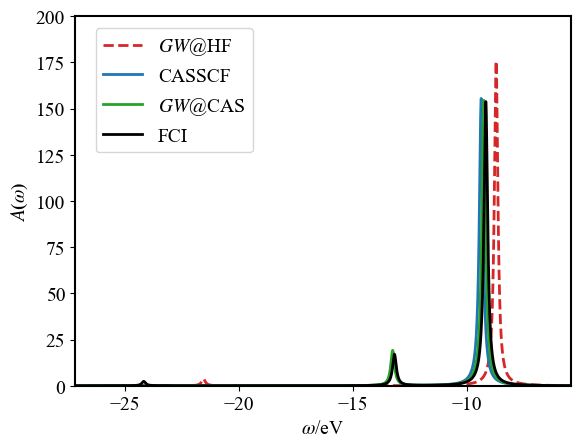

In [ ]:
from gf.gw.addons import read_spec_dat
from scipy.signal import find_peaks
import matplotlib.pylab as plt

freq, spec = read_spec_dat('Be-GW@HF.dat')
plt.plot(freq*au2ev, spec, label=r'$GW$@HF', color=color_dict['GW0'], ls='--')

pk,_ = find_peaks(spec, height=.1)
print('GW@HF peaks, ', freq[pk]*au2ev)

freq, spec = read_spec_dat('Be-CAS.dat')
plt.plot(freq*au2ev, spec, label='CASSCF', color=color_dict['CASSCF'])

pk,_ = find_peaks(spec, height=.1)
print('CASCI peaks, ', freq[pk]*au2ev)

freq, spec = read_spec_dat('Be-GW@CAS.dat')
plt.plot(freq*au2ev, spec, label=r'$GW$@CAS', color=color_dict['GW2'])

pk,_ = find_peaks(spec, height=.1)
print('GW@CAS peaks, ', freq[pk]*au2ev)

freq, spec = read_spec_dat('Be-FCI.dat')
plt.plot(freq*au2ev, spec, label='FCI', color=color_dict['FCI'])

pk,_ = find_peaks(spec, height=.1)
print('FCI peaks, ', freq[pk]*au2ev)

plt.xlim(-au2ev,-.2*au2ev)
plt.ylim(0,200)

plt.xlabel(r'$\omega$/eV')
plt.ylabel(r'$A(\omega)$')

plt.legend(loc='center', bbox_to_anchor=(.2,.8))

plt.savefig('Be-spec.pdf', format='pdf')

Satellite: one p electron

CASCI peaks,  [-0.48682118 -0.3446013   0.14195973]
MRGW peaks,  [-1.28685393 -1.20821038 -1.15014645 -0.6102989  -0.48755617 -0.34055888
  0.09418561]


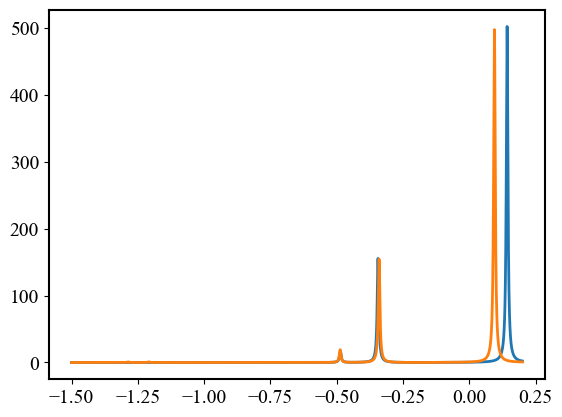

In [ ]:
from scipy.signal import find_peaks

freq, spec = read_spec_dat('Be-CAS.dat')
plt.plot(freq, spec, label='CAS')

pk,_ = find_peaks(spec, height=.1)

print('CASCI peaks, ', freq[pk])

freq, spec = read_spec_dat('Be-GW@CAS.dat')
plt.plot(freq, spec, label='GW@CAS')

pk,_ = find_peaks(spec, height=.1)

print('MRGW peaks, ', freq[pk])

In [ ]:
from gf.gw.srgw import selfen_FCI

sigma_fci = selfen_FCI(rhf)

======== Ground state FCI coefficients ========
    det-alpha,    det-beta,    CI coefficients
       [0 1]       [0 1]      0.948648577678
       [0 2]       [0 2]      -0.162817607903
       [0 3]       [0 3]      -0.162817651297
       [0 4]       [0 4]      -0.162817159154
======== Electron addition: alpha ========
State id =    0, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 3]       [0 1]      0.162350530617
       [0 1 4]       [0 1]      0.940455431411
       [0 2 4]       [0 2]      -0.177798198124
       [0 3 4]       [0 3]      -0.177798198124
State id =    1, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 3]       [0 1]      -0.940455430705
       [0 2 3]       [0 2]      0.177798197991
       [0 1 4]       [0 1]      0.162350530495
       [0 3 4]       [0 4]      -0.177798197991
State id =    2, EA =    0.0847891816
    det-alpha,    det-beta,    CI coefficients
       [0 1 2]       [0 1]      0.9543658166

In [ ]:

W = np.arange(-2, .5, .2*eta)

sigma_gw_rhf = selfen_GW_RHF(rhf, eta=0.)

nfreq = len(W)

dat_gw_rhf = np.zeros([4,nfreq])
dat_s0 = np.zeros([4,nfreq])
dat_s0gw = np.zeros([4,nfreq])
dat_s0sosex = np.zeros([4,nfreq])


cas.verbose = 4

casgw = CASGW(cas, ss=0.)

sigma0, sigma_gw_cas = casgw.connect_to_sr(rhf)
_, sigma_sosex_cas = casgw.connect_to_sr(rhf, sosex=True)


#sigma0, sigma_gw_cas = casgw.connect_to_sr(rhf, so)


#sigma_gw_cas,_,_,_ = casgw.selfen_GW(ss=0., eta=0.)

idxsr = [1,4,5,6]
idxmr = [1,4,5,6]

for i_freq,w in enumerate(W):
    for i_orb in range(4):
        dat_gw_rhf[i_orb][i_freq] = sigma_gw_rhf(w)[idxsr[i_orb],idxsr[i_orb]].real
        dat_s0[i_orb][i_freq] = sigma0(w)[idxmr[i_orb],idxmr[i_orb]].real 
        dat_s0gw[i_orb][i_freq] = sigma0(w)[idxmr[i_orb],idxmr[i_orb]].real + sigma_gw_cas(w)[idxmr[i_orb],idxmr[i_orb]].real
        dat_s0sosex[i_orb][i_freq] = sigma0(w)[idxmr[i_orb],idxmr[i_orb]].real + sigma_sosex_cas(w)[idxmr[i_orb],idxmr[i_orb]].real


E(RPA,corr) =    -0.0370631413
Lowest     8 RPA excitation energies:
 [0.38373073 0.38373073 0.38373073 0.48506062 0.48506062 0.48506062
 0.7410497  0.76622639]
Ee and tdm are constructed: ph, p, h
S^2 of target state:   0.00000
Excitations in the CAS space
 EE =    0.2670811531
 EA =    0.1418535397
 EA(a) =    0.1418535397
   Principle components (a) :
     det-alpha,    det-beta,    CI coefficients
     [0 1]       [0]      -0.341512941867
     [0 2]       [0]      0.893078723260
     [1 2]       [1]      -0.173798041848
     [0 3]       [0]      -0.123974612183
     [2 3]       [3]      0.173798033798
 EA(b) =    0.1418535397
   Principle components (b) :
     det-alpha,    det-beta,    CI coefficients
     [0]       [0 1]      -0.341512933534
     [0]       [0 2]      0.893078727854
     [0]       [0 3]      -0.123974602044
     [1]       [1 2]      -0.173798042742
     [3]       [2 3]      0.173798034692
 IP =    0.3447371223
 IP(a) =    0.3447371223
   Principle components (a) :

In [ ]:
dat_fci = np.zeros([4,nfreq])

idx = [1,2,3,4]

for i_freq,w in enumerate(W):
    for i_orb in range(4):
        dat_fci[i_orb][i_freq] = sigma_fci(w)[idx[i_orb],idx[i_orb]].real 

In [ ]:
from scipy.signal import find_peaks

def plot_split(ax, w, A, **kwargs):

    split, _ = find_peaks(np.abs(A))

    N = len(split)+1

    split_ext = np.hstack([[0], split, len(w)])

    kwargs1 = kwargs.copy()

    if 'label' in kwargs1.keys():
        kwargs1['label'] = None

    for i in range(N):
        i0 = split_ext[i]
        i1 = split_ext[i+1]
        x_branch = w[i0+1:i1]
        y_branch = A[i0+1:i1]

        if (i==0):
            ax.plot(x_branch, y_branch, **kwargs)
        else:
            ax.plot(x_branch, y_branch, **kwargs1)



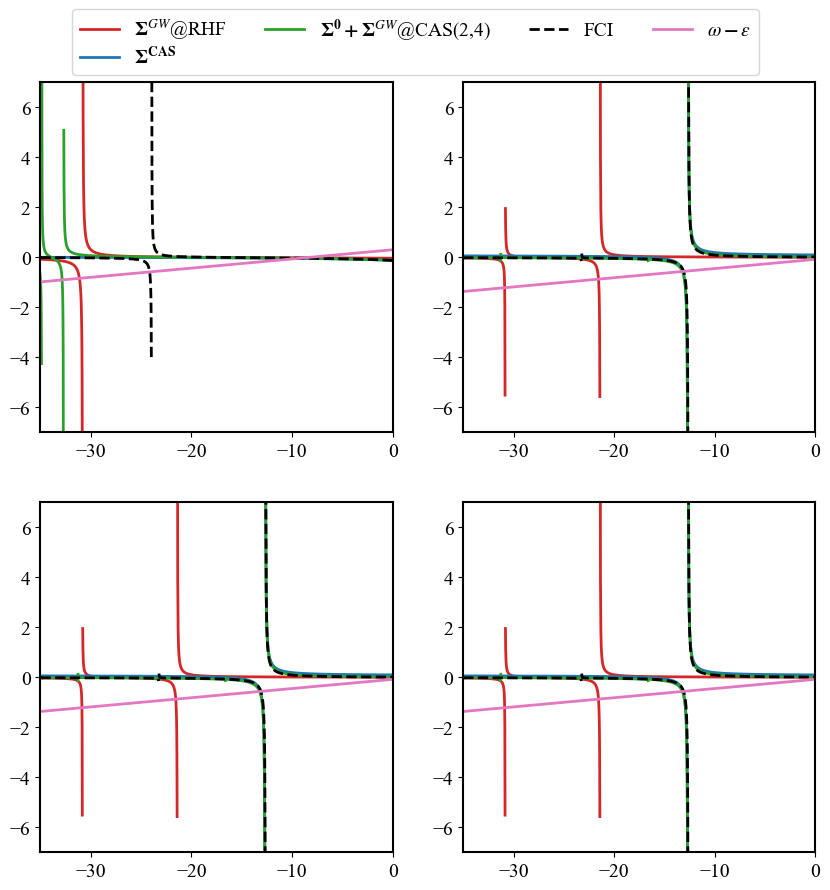

In [ ]:

fig, [[ax1,ax2],[ax3,ax4]] = plt.subplots(nrows=2, ncols=2, figsize=(10,10))


for i,ax in enumerate([ax1,ax2,ax3,ax4]):
    
    #ax.plot(W*au2ev, dat_gw_rhf[i], color=color_dict['GW0'], label=r'$\Sigma^{GW}$@RHF', lw=1)
    plot_split(ax, W*au2ev, dat_gw_rhf[i], color=color_dict['GW0'], label=r'$\Sigma^{GW}$@RHF')

    #ax.plot(W*au2ev, dat_s0[i], color=color_dict['CASSCF'], label=r'$\Sigma^\text{CAS}$', lw=1)
    plot_split(ax, W*au2ev, dat_s0[i], color=color_dict['CASSCF'], label=r'$\Sigma^\text{CAS}$')

    #ax.plot(W*au2ev, dat_s0gw[i], color=color_dict['GW1'], label=r'$\Sigma^{GW}$@CAS(2,4)', lw=1)
    plot_split(ax, W*au2ev, dat_s0gw[i], color=color_dict['GW2'], label=r'$\Sigma^0+\Sigma^{GW}$@CAS(2,4)')

    plot_split(ax, W*au2ev, dat_fci[i], color='black', label='FCI', ls='--')

    ax.plot(W*au2ev, W-rhf.mo_energy[i+1], color='tab:pink', label=r'$\omega-\epsilon$')

    ax.set_xlim(-35,0)
    ax.set_ylim(-7,7)

#plt.legend()



lines, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="center", bbox_to_anchor=(.5,.92), ncol=4, labelspacing=.2)

fig.savefig('se-tmp.pdf', format='pdf')

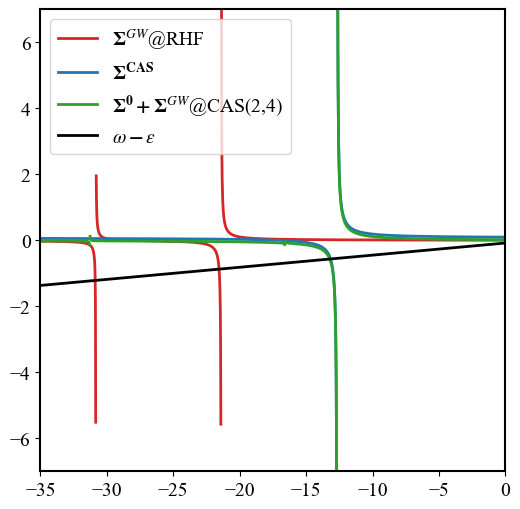

In [ ]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))

i=3
    
#ax.plot(W*au2ev, dat_gw_rhf[i], color=color_dict['GW0'], label=r'$\Sigma^{GW}$@RHF', lw=1)
plot_split(ax, W*au2ev, dat_gw_rhf[i], color=color_dict['GW0'], label=r'$\Sigma^{GW}$@RHF')

#ax.plot(W*au2ev, dat_s0[i], color=color_dict['CASSCF'], label=r'$\Sigma^\text{CAS}$', lw=1)
plot_split(ax, W*au2ev, dat_s0[i], color=color_dict['CASSCF'], label=r'$\Sigma^\text{CAS}$')

#ax.plot(W*au2ev, dat_s0gw[i], color=color_dict['GW1'], label=r'$\Sigma^{GW}$@CAS(2,4)', lw=1)
plot_split(ax, W*au2ev, dat_s0gw[i], color=color_dict['GW2'], label=r'$\Sigma^0+\Sigma^{GW}$@CAS(2,4)')

ax.plot(W*au2ev, W-rhf.mo_energy[i+1], color='black', label=r'$\omega-\epsilon$')

ax.set_xlim(-35,0)
ax.set_ylim(-7,7)


#plt.legend()
ax.legend()


dat_gw_rhf[i].tofile('se_2p_gw_rhf.dat', format='binary')
dat_s0[i].tofile('se_2p_s0.dat', format='binary')
dat_s0gw[i].tofile('se_2p_s0gw.dat', format='binary')
dat_s0sosex[i].tofile('se_2p_s0sosex.dat', format='binary')
dat_fci[i].tofile('se_2p_fci.dat', format='binary')

i = 0

dat_gw_rhf[i].tofile('se_2s_gw_rhf.dat', format='binary')
dat_s0[i].tofile('se_2s_s0.dat', format='binary')
dat_s0gw[i].tofile('se_2s_s0gw.dat', format='binary')
dat_s0sosex[i].tofile('se_2s_s0sosex.dat', format='binary')
dat_fci[i].tofile('se_2s_fci.dat', format='binary')


lines, labels = fig.axes[0].get_legend_handles_labels()
#fig.legend(lines, labels, loc="center", bbox_to_anchor=(.5,.92), ncol=3, labelspacing=.2)